# SmartCart ETL and Hypothesis Analysis

This notebook loads the raw shopping data, cleans and standardises it, saves `cleaned_customer_shopping_data.csv`, and tests business hypotheses using the cleaned dataset.

## Objectives

This notebook provides the ETL and exploratory analysis foundation for the SmartCart Analytics project. It prepares raw customer-shopping transactions for reliable analysis and downstream machine-learning use by:

* Loading the raw shopping dataset and inspecting its structure, data types, and missing values.
* Cleaning text fields, standardising dates, and resolving meaningful missing values.
* Creating analysis-ready features such as purchase year, purchase month, day of week, return indicators, subscription indicators, and purchase-frequency days.
* Saving a consistent cleaned dataset for the machine-learning pipeline and Streamlit dashboard.
* Testing ten business hypotheses about returns, discounts, shipping, customer preferences, loyalty, payments, and product sizing.
* Producing tables and visualisations that communicate patterns to SmartCart stakeholders.

## Inputs

* `dataset/customer_shopping_behavior.csv` — the raw customer transaction dataset.
* Python packages including `pandas`, `numpy`, `matplotlib`, and `seaborn`.
* The dataset fields used in the analysis, including customer demographics, product details, purchase amounts, discounts, delivery information, payment methods, ratings, subscriptions, and return status.
* A working directory configured so the notebook can locate the project dataset and save generated outputs in the project root.

## Outputs

* `cleaned_customer_shopping_data.csv` — the cleaned and feature-engineered dataset saved in the project root.
* Data-quality summaries covering shape, data types, missing values, and descriptive statistics.
* Hypothesis summary tables for festival activity, discount bands, shipping, delivery time, demographics, location, subscriptions, ratings, payment methods, and product combinations.
* Static charts that support interpretation of the ten hypotheses.
* Analysis variables that can be reused by `ML_PipeLine.ipynb` and the Streamlit application, including `Is_Returned`, `Is_Subscribed`, `Purchase_Frequency_Days`, and grouped summary data.

## Additional Comments

* ETL is completed before hypothesis testing so that inconsistent whitespace, dates, missing values, and categorical labels do not distort the results.
* The analysis describes associations in completed transactions; it does not establish causation. Statistical tests, confidence intervals, and additional operational data should be used before making business decisions.
* Cart abandonment cannot be measured directly because the dataset contains completed purchases rather than abandoned carts. Purchase amount is used only as a stated proxy when discussing shipping effects.
* The minimum transaction threshold used for product return-rate combinations reduces the influence of very small groups.
* The cleaned dataset is shared with the machine-learning notebook, which provides return-risk classification and customer-value regression prototypes. The Streamlit app provides the stakeholder-facing interactive filters, Plotly charts, and prediction forms.

## 📉 Goal 1: Reducing Returns (Classification)The goal is to predict which transactions are likely to result in a Return Status (Yes/No) so you can flag risky orders or optimize sizing/descriptions.

## 💎 Goal 2: Predicting High-Value Customers (Regression / Segmentation)The goal is to predict a customer's Future Value or identify high-tier shoppers. We can aggregate data by Customer ID to calculate their total spend and predict it using loyalty metrics.

## 🏷️ Goal 3: Optimizing Discounts (Price Elasticity & Analytics)To optimize discounts, we need to understand the sweet spot where Discount (%) maximizes Quantity or Purchase Amount (₹) without destroying profit margins, especially during a Festival/Sale.


# 🛍️ Festival and Discount DynamicsHypothesis 
* Hypothesis 1: Transactions marked as "Festival/Sale" will have significantly higher "Purchase Amount (₹)" and "Quantity" compared to regular days, but lower average "Review Rating" due to delivery delays.
* Hypothesis 2: High "Discount (%)" levels positively correlate with increased "Quantity" per transaction, but also lead to a higher "Return Status" rate.
🚚 Shipping and Fulfillment Effects.
* Hypothesis 3: Orders with higher "Shipping Charge (₹)" exhibit higher cart abandonment rates (or lower overall "Purchase Amount") unless the "Delivery Speed" is set to express.
* Hypothesis 4: A "Delivery Time (Days)" exceeding 5 days results in a measurable drop in "Review Rating" for "Online Store" transactions.

👤 Demographics and Category Preferences.
* Hypothesis 5: "Age" and "Gender" significantly influence the "Category" and "Brand" chosen (e.g., younger demographics favor specific trendy brands or online shopping over offline).
* Hypothesis 6: Customers in specific "Location" clusters (e.g., Tier 1 vs Tier 2 cities) show a strong preference for "Online" vs "Offline" shopping channels.


🔁 Customer Loyalty and Retention.
* Hypothesis 7: Customers with an active "Subscription Status" have a higher "Frequency of Purchases" and a higher number of "Previous Purchases" than non-subscribers.
* Hypothesis 8: High "Review Rating" scores on the current purchase are strong predictors of a shorter interval in the "Frequency of Purchases" for the next transaction.

💳 Payment and Sizing Behavior
* Hypothesis 9: Digital "Payment Method" choices (like UPI or Credit Cards) are associated with higher "Purchase Amount (₹)" compared to Cash on Delivery (CoD).
* Hypothesis 10: Certain "Size" and "Color" combinations within specific apparel "Categories" suffer from disproportionately high "Return Status" rates due to sizing inconsistencies.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\User\\Desktop\\Data Analysis with AI Course\\Code Institute\\vscode-projects\\SmartCart_Analytics\\SmartCart_Analytics\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\User\\Desktop\\Data Analysis with AI Course\\Code Institute\\vscode-projects\\SmartCart_Analytics\\SmartCart_Analytics'

# Read and Transform Data to panda DataFrame

# Section 1 
* Read The Input Data
* Load to Panda's DataFrame

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

file_name = "dataset/customer_shopping_behavior.csv"
matches = list(Path.cwd().parent.rglob(file_name))

if not matches:
  raise FileNotFoundError(
    f"{file_name} was not found under {Path.cwd()}. "
    "Check that the dataset file is in the project folder."
  )

df = pd.read_csv(matches[0])
print('Dataframe loaded successfully')
print(df.shape)
df.head()

Dataframe loaded successfully
(10000, 26)


,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN507808,CUST102534,2023-01-01,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,NaN,0,Same Day,1,Yes,Cash on Delivery,4,Not Returned,0,Fortnightly
1,TXN503830,CUST101256,2023-01-01,27,Female,Mumbai,Offline,NaN,Clothing,Shirt,...,NaN,0,NaN,0,No,UPI,5,Not Returned,0,Fortnightly
2,TXN501496,CUST100490,2023-01-01,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,NaN,0,Standard,7,Yes,UPI,3,Not Returned,0,Rarely
3,TXN501538,CUST100500,2023-01-01,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,NaN,0,Standard,6,Yes,Net Banking,4,Not Returned,0,Fortnightly
4,TXN504265,CUST101399,2023-01-01,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,NaN,99,Express,2,No,Debit Card,4,Not Returned,0,Weekly


---

# Section 1.2
### Explore the Data

Gettingt the dtypes of columns which can be numerical or catogorical

In [5]:
#discovering the shape of the dataset and the column names
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Transaction ID          10000 non-null  object
 1   Customer ID             10000 non-null  object
 2   Purchase Date           10000 non-null  object
 3   Age                     10000 non-null  int64 
 4   Gender                  10000 non-null  object
 5   Location                10000 non-null  object
 6   Online/Offline          10000 non-null  object
 7   Online Store            7751 non-null   object
 8   Category                10000 non-null  object
 9   Item Purchased          10000 non-null  object
 10  Brand                   10000 non-null  object
 11  Color                   10000 non-null  object
 12  Size                    8965 non-null   object
 13  Quantity                10000 non-null  int64 
 14  Purchase Amount (₹)     10000 non-null  int64 
 15  Dis

---

In [6]:
# view all columns in data set
df.columns

Index(['Transaction ID', 'Customer ID', 'Purchase Date', 'Age', 'Gender',
       'Location', 'Online/Offline', 'Online Store', 'Category',
       'Item Purchased', 'Brand', 'Color', 'Size', 'Quantity',
       'Purchase Amount (₹)', 'Discount (%)', 'Festival/Sale',
       'Shipping Charge (₹)', 'Delivery Speed', 'Delivery Time (Days)',
       'Subscription Status', 'Payment Method', 'Review Rating',
       'Return Status', 'Previous Purchases', 'Frequency of Purchases'],
      dtype='object')

In [7]:
# check data types of each column
df.dtypes

Transaction ID            object
Customer ID               object
Purchase Date             object
Age                        int64
Gender                    object
Location                  object
Online/Offline            object
Online Store              object
Category                  object
Item Purchased            object
Brand                     object
Color                     object
Size                      object
Quantity                   int64
Purchase Amount (₹)        int64
Discount (%)               int64
Festival/Sale             object
Shipping Charge (₹)        int64
Delivery Speed            object
Delivery Time (Days)       int64
Subscription Status       object
Payment Method            object
Review Rating              int64
Return Status             object
Previous Purchases         int64
Frequency of Purchases    object
dtype: object

In [8]:
# check the summary statistics of the dataset
df.describe()

,Age,Quantity,Purchase Amount (₹),Discount (%),Shipping Charge (₹),Delivery Time (Days),Review Rating,Previous Purchases
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,38.278100,1.425100,1889.882000,32.916300,41.49210,3.703600,3.874900,3.211400
std,12.133041,0.761346,2102.301836,21.440617,64.30923,2.726223,0.912871,3.951313
min,18.000000,1.000000,67.000000,0.000000,0.00000,0.000000,1.000000,0.000000
25%,28.000000,1.000000,600.000000,12.000000,0.00000,1.000000,3.000000,0.000000
50%,38.000000,1.000000,1207.000000,33.000000,0.00000,4.000000,4.000000,2.000000
75%,49.000000,2.000000,2376.000000,52.000000,79.00000,6.000000,5.000000,4.000000
max,59.000000,4.000000,22306.000000,70.000000,199.00000,8.000000,5.000000,28.000000


# Conclusion :
### Why ETL Must Come First than EDA

Looking Closely at the raw data 
* Fields like Purchase Date are stored as raw strings (2023-01-01).
* Festival/Sale is flagged as an empty object type in the schema. It likely contains text strings or missing fields that need formatting.
* Frequency of Purchases uses categorical strings like Weekly or Fortnightly.
* Text columns contain whitespace variability (e.g., 'Returned ' vs 'Not Returned').

If we run EDA before fixing these, our charts will break, date-based trends won't plot, and categories will duplicate due to hidden whitespaces.

# Section 2
# ETL Pipeline

### clean, standardise, and structure our dataset into a high-utility format.

In [9]:
# 1. Structural Inspection
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Data Types & Missing Values ---")
print(df.info())



--- Dataset Shape ---
(10000, 26)

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Transaction ID          10000 non-null  object
 1   Customer ID             10000 non-null  object
 2   Purchase Date           10000 non-null  object
 3   Age                     10000 non-null  int64 
 4   Gender                  10000 non-null  object
 5   Location                10000 non-null  object
 6   Online/Offline          10000 non-null  object
 7   Online Store            7751 non-null   object
 8   Category                10000 non-null  object
 9   Item Purchased          10000 non-null  object
 10  Brand                   10000 non-null  object
 11  Color                   10000 non-null  object
 12  Size                    8965 non-null   object
 13  Quantity                10000 non-nu

In [10]:
# 2. Check for explicit missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
Transaction ID               0
Customer ID                  0
Purchase Date                0
Age                          0
Gender                       0
Location                     0
Online/Offline               0
Online Store              2249
Category                     0
Item Purchased               0
Brand                        0
Color                        0
Size                      1035
Quantity                     0
Purchase Amount (₹)          0
Discount (%)                 0
Festival/Sale             6788
Shipping Charge (₹)          0
Delivery Speed            2249
Delivery Time (Days)         0
Subscription Status          0
Payment Method               0
Review Rating                0
Return Status                0
Previous Purchases           0
Frequency of Purchases       0
dtype: int64


In [11]:
 # 3. Transform: Clean string columns & strip whitespaces
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

print(string_cols)

Index(['Transaction ID', 'Customer ID', 'Purchase Date', 'Gender', 'Location',
       'Online/Offline', 'Online Store', 'Category', 'Item Purchased', 'Brand',
       'Color', 'Size', 'Festival/Sale', 'Delivery Speed',
       'Subscription Status', 'Payment Method', 'Return Status',
       'Frequency of Purchases'],
      dtype='object')


In [12]:
# 4. Transform: Standardise Datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df['Purchase_Year'] = df['Purchase Date'].dt.year
df['Purchase_Month'] = df['Purchase Date'].dt.month
df['Purchase_DayOfWeek'] = df['Purchase Date'].dt.dayofweek

In [13]:
# 5. Transform: Handle 'Festival/Sale' Missing Values
# Treat true nulls, empty strings, whitespace, and text such as 'nan' as regular days.
festival_sale = df['Festival/Sale'].astype('string').str.strip()
missing_festival_sale = (
    festival_sale.isna()
    | festival_sale.str.lower().isin(['', 'nan', 'none', 'null'])
)
df.loc[missing_festival_sale, 'Festival/Sale'] = 'Regular Day'

print("Missing 'Festival/Sale' values after cleaning:", df['Festival/Sale'].isna().sum())
print("Null-like text values remaining:", df['Festival/Sale'].astype('string').str.strip().str.lower().isin(
    ['', 'nan', 'none', 'null']
).sum())

Missing 'Festival/Sale' values after cleaning: 0
Null-like text values remaining: 0


In [14]:
# 6. Transform: Handle 'Online Store' Missing Values
# Assuming Missing value for 'Online/Offline' as Offline store sale hence missing value can be replaced by 'Local Store'
for i in df.index:
    online_store = df.loc[i, 'Online Store']

    if (
        (pd.isna(online_store) or
         str(online_store).strip().lower() == 'nan')
        and str(df.loc[i, 'Online/Offline']).strip().lower() == 'offline'
    ):
        df.loc[i, 'Online Store'] = 'Not online store'

In [15]:
# 7. Transform: Handle 'Size' Missing Values
df['Size'] = df['Size'].fillna('Unknown')
Size = df['Size'].astype('string').str.strip()
missing_Size = (
    Size.isna()
    | Size.str.lower().isin(['', 'nan', 'none', 'null'])
)
df.loc[missing_Size, 'Size'] = 'Unknown'

In [16]:
# 8. Transform: Handle 'Delivery Speed' Missing Values
# Offline purchases do not require a delivery service, so use 'Hands On'.
delivery_speed = df['Delivery Speed'].astype('string').str.strip()
channel = df['Online/Offline'].astype('string').str.strip().str.lower()
missing_delivery_speed = (
    delivery_speed.isna()
    | delivery_speed.str.lower().isin(['', 'nan', 'none', 'null'])
)
offline_orders = channel.eq('offline')
df.loc[missing_delivery_speed & offline_orders, 'Delivery Speed'] = 'Hands On'

print(
    "Offline orders updated:",
    (missing_delivery_speed & offline_orders).sum()
)
print(
    "Missing Delivery Speed values remaining for offline orders:",
    df.loc[offline_orders, 'Delivery Speed'].isna().sum()
)

Offline orders updated: 2249
Missing Delivery Speed values remaining for offline orders: 0


In [17]:
# 9. Transform: Standardise Targets
df['Is_Returned'] = df['Return Status'].apply(lambda x: 1 if x.lower() == 'returned' else 0)
df['Is_Subscribed'] = df['Subscription Status'].apply(lambda x: 1 if x.lower() == 'yes' else 0)

In [18]:
# 10. Transform: Map Frequency to Ordinal Numbers (For correlation analysis)
freq_map = {'Weekly': 7, 'Fortnightly': 14, 'Monthly': 30, 'Quarterly': 90, 'Rarely': 180}
df['Purchase_Frequency_Days'] = df['Frequency of Purchases'].map(freq_map)

In [19]:
# 11. Re-check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
Transaction ID             0
Customer ID                0
Purchase Date              0
Age                        0
Gender                     0
Location                   0
Online/Offline             0
Online Store               0
Category                   0
Item Purchased             0
Brand                      0
Color                      0
Size                       0
Quantity                   0
Purchase Amount (₹)        0
Discount (%)               0
Festival/Sale              0
Shipping Charge (₹)        0
Delivery Speed             0
Delivery Time (Days)       0
Subscription Status        0
Payment Method             0
Review Rating              0
Return Status              0
Previous Purchases         0
Frequency of Purchases     0
Purchase_Year              0
Purchase_Month             0
Purchase_DayOfWeek         0
Is_Returned                0
Is_Subscribed              0
Purchase_Frequency_Days    0
dtype: int64


In [20]:
# 12. Load: Save clean baseline
# Locate the project folder from its dataset, then save the output there.
dataset_matches = list(Path.cwd().rglob('dataset/customer_shopping_behavior.csv'))

if not dataset_matches:
    raise FileNotFoundError(
        "The project dataset could not be found from the current working directory."
    )

project_root = dataset_matches[0].parent.parent
output_path = project_root / 'cleaned_customer_shopping_data.csv'
df.to_csv(output_path, index=False)

if not output_path.exists():
    raise FileNotFoundError(f'Output file was not created: {output_path}')

print(f'ETL Pipeline completed successfully! Clean file saved to: {output_path.resolve()}')
print(f'Output file size: {output_path.stat().st_size:,} bytes')

ETL Pipeline completed successfully! Clean file saved to: C:\Users\User\Desktop\Data Analysis with AI Course\Code Institute\vscode-projects\SmartCart_Analytics\SmartCart_Analytics\cleaned_customer_shopping_data.csv
Output file size: 1,884,789 bytes


In [21]:
# Hypothesis testing using the cleaned ETL output
import pandas as pd
from pathlib import Path

frequency_days = {
    'Weekly': 7,
    'Fortnightly': 14,
    'Monthly': 30,
    'Quarterly': 90,
    'Rarely': 180
}

cleaned_candidates = [
    Path.cwd() / 'cleaned_customer_shopping_data.csv',
    Path.cwd().parent / 'cleaned_customer_shopping_data.csv'
]
cleaned_path = next((path for path in cleaned_candidates if path.exists()), None)

if cleaned_path is None:
    raise FileNotFoundError(
        'cleaned_customer_shopping_data.csv was not found. Run the ETL save step first.'
    )

df_clean = pd.read_csv(cleaned_path)
df_clean['Purchase Date'] = pd.to_datetime(df_clean['Purchase Date'], errors='coerce')
df_clean['Purchase_Frequency_Days'] = df_clean['Frequency of Purchases'].map(frequency_days)
df_clean['Is_Returned'] = (
    df_clean['Return Status'].astype('string').str.strip().str.lower().eq('returned').astype(int)
)

# H1: Festival/Sale versus regular-day outcomes.
festival_summary = df_clean.groupby('Festival/Sale').agg(
    average_purchase=('Purchase Amount (₹)', 'mean'),
    average_quantity=('Quantity', 'mean'),
    average_rating=('Review Rating', 'mean'),
    transactions=('Customer ID', 'size')
).round(2)
print('H1 - Festival/Sale summary:')
display(festival_summary)

# H2: Discount relationships with quantity and return rate.
df_clean['Discount_Band'] = pd.cut(
    df_clean['Discount (%)'],
    bins=[-1, 10, 20, 30, 40, 100],
    labels=['0-10%', '11-20%', '21-30%', '31-40%', '41%+']
)
discount_summary = df_clean.groupby('Discount_Band', observed=False).agg(
    average_quantity=('Quantity', 'mean'),
    return_rate=('Is_Returned', 'mean'),
    transactions=('Customer ID', 'size')
).round(3)
print('H2 - Discount bands:')
display(discount_summary)
print('H2 - Correlation:')
print(df_clean[['Discount (%)', 'Quantity', 'Is_Returned']].corr().round(3))

# H3: Shipping charge and delivery speed. Cart abandonment is unavailable,
# so purchase amount is used as the stated proxy.
shipping_corr = df_clean[['Shipping Charge (₹)', 'Purchase Amount (₹)']].corr().iloc[0, 1]
shipping_summary = df_clean.groupby('Delivery Speed').agg(
    average_shipping=('Shipping Charge (₹)', 'mean'),
    average_purchase=('Purchase Amount (₹)', 'mean'),
    transactions=('Customer ID', 'size')
).round(2)
print(f'H3 - Shipping charge/purchase correlation: {shipping_corr:.3f}')
display(shipping_summary)

# H4: Online orders delivered in more than five days.
online_orders = df_clean[
    df_clean['Online/Offline'].astype('string').str.strip().str.lower().eq('online')
].copy()
online_orders['Slow_Delivery'] = online_orders['Delivery Time (Days)'] > 5
h4_summary = online_orders.groupby('Slow_Delivery').agg(
    average_rating=('Review Rating', 'mean'),
    transactions=('Customer ID', 'size')
).round(2)
print('H4 - Online delivery-time groups:')
display(h4_summary)

# H5: Category and brand preferences by age group and gender.
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'], bins=[0, 25, 40, 60, 120],
    labels=['18-25', '26-40', '41-60', '61+']
)
h5_category = pd.crosstab(df_clean['Age_Group'], df_clean['Category'], normalize='index').round(3)
h5_gender = pd.crosstab(df_clean['Gender'], df_clean['Category'], normalize='index').round(3)
print('H5 - Category share by age group:')
display(h5_category)
print('H5 - Category share by gender:')
display(h5_gender)

# H6: Online preference by location.
h6_location = df_clean.groupby('Location').agg(
    online_share=('Online/Offline', lambda values: values.astype('string').str.strip().str.lower().eq('online').mean()),
    transactions=('Customer ID', 'size')
).sort_values('online_share', ascending=False).round(3)
print('H6 - Online share by location:')
display(h6_location)

# H7: Subscription status versus loyalty measures.
h7_subscription = df_clean.groupby('Subscription Status').agg(
    average_previous_purchases=('Previous Purchases', 'mean'),
    average_frequency_days=('Purchase_Frequency_Days', 'mean'),
    transactions=('Customer ID', 'size')
).round(2)
print('H7 - Subscription and loyalty summary:')
display(h7_subscription)

# H8: Review rating versus purchase-frequency interval.
h8_correlation = df_clean[['Review Rating', 'Purchase_Frequency_Days']].corr().iloc[0, 1]
print(f'H8 - Rating/frequency-days correlation: {h8_correlation:.3f}')

# H9: Payment method and average purchase amount.
h9_payment = df_clean.groupby('Payment Method').agg(
    average_purchase=('Purchase Amount (₹)', 'mean'),
    transactions=('Customer ID', 'size')
).sort_values('average_purchase', ascending=False).round(2)
print('H9 - Purchase amount by payment method:')
display(h9_payment)

# H10: Return rates for category-size-colour combinations with enough observations.
h10_groups = df_clean.groupby(
    ['Category', 'Size', 'Color'], observed=True
).agg(
    return_rate=('Is_Returned', 'mean'),
    transactions=('Customer ID', 'size')
).query('transactions >= 30').sort_values('return_rate', ascending=False).head(10).round(3)
print('H10 - Highest return-rate combinations (minimum 30 transactions):')
display(h10_groups)

H1 - Festival/Sale summary:


,average_purchase,average_quantity,average_rating,transactions
Festival/Sale,,,,
Amazon Great Summer Sale,1290.69,1.37,3.81,432
Big Billion Days,1226.41,1.37,3.72,467
Diwali Sale,1194.81,1.43,3.87,451
End of Season Sale,1325.75,1.42,3.80,517
Holi Sale,1334.77,1.41,3.80,455
Independence Day Sale,1305.80,1.45,3.79,453
Regular Day,2175.41,1.43,3.91,6788
Republic Day Sale,1324.24,1.46,3.82,437


H2 - Discount bands:


,average_quantity,return_rate,transactions
Discount_Band,,,
0-10%,1.417,0.193,2213
11-20%,1.413,0.206,1145
21-30%,1.472,0.186,1376
31-40%,1.412,0.154,1214
41%+,1.421,0.172,4052


H2 - Correlation:
              Discount (%)  Quantity  Is_Returned
Discount (%)         1.000    -0.001       -0.026
Quantity            -0.001     1.000        0.016
Is_Returned         -0.026     0.016        1.000
H3 - Shipping charge/purchase correlation: -0.088


...

,average_previous_purchases,average_frequency_days,transactions
Subscription Status,,,
No,3.34,24.86,6881
Yes,2.93,26.34,3119


H8 - Rating/frequency-days correlation: 0.021
H9 - Purchase amount by payment method:


,average_purchase,transactions
Payment Method,,
EMI,2279.01,430
Credit Card,2218.82,1582
Wallet,1911.88,471
Net Banking,1873.17,586
UPI,1870.02,4411
Debit Card,1850.15,1533
Cash on Delivery,1342.99,987


H10 - Highest return-rate combinations (minimum 30 transactions):


return_rate  transactions
Category Size Color                            
Footwear 10   Blue          0.436            39
         9    Brown         0.308            52
         8    Red           0.297            37
         6    Green         0.294            34
Clothing XS   White         0.290            31
Footwear 7    White         0.277            47
         9    Grey          0.273            44
              Green         0.273            44
         11   Yellow        0.273            44
Clothing XL   Navy          0.273            77

## Hypothesis Interpretations and Conclusions

The following conclusions should be based on the tables printed above. Differences describe associations in this dataset; they do not prove that one variable causes another.

1. **Festival and discount dynamics:** H1 is supported only if Festival/Sale rows show higher average purchase amount and quantity, while also showing a lower average rating. H2 is supported if quantity and return rate generally increase across discount bands. Use the correlation values as supporting evidence, not as proof of causation.
2. **Shipping and fulfilment:** H3 uses purchase amount as a proxy because cart-abandonment data is not available. A negative shipping-charge/purchase correlation would support the hypothesis. H4 is supported if online orders taking more than five days have a lower average rating than faster orders.
3. **Demographics and preferences:** H5 is supported when category shares vary noticeably across age groups or genders. H6 is supported when online-share percentages differ meaningfully by location; this is evidence of preference, not a formal geographic cluster analysis.
4. **Loyalty and retention:** H7 is supported if subscribers have higher average previous purchases and purchase frequency than non-subscribers. H8 is supported only if the rating/frequency-days correlation is negative, meaning higher ratings are associated with shorter intervals. Correlation alone cannot establish that ratings predict future behaviour.
5. **Payment and sizing:** H9 is supported if digital payment methods have higher average purchase amounts than Cash on Delivery. H10 identifies category-size-colour combinations with elevated return rates while requiring at least 30 transactions, reducing the risk of conclusions based on very small groups.

### Overall conclusion

The hypothesis tables provide an evidence-based overview of SmartCart customer behaviour and highlight areas for further investigation. The strongest findings should be confirmed with statistical tests, confidence intervals, and additional data such as cart-abandonment records, profit margins, delivery-service details, and customer-level transaction history before operational decisions are made.

## Hypothesis Visualisations

The following graphs visualise the summary tables calculated from `cleaned_customer_shopping_data.csv`. Each chart is designed to make the main comparison in the related hypotheses easier to interpret.

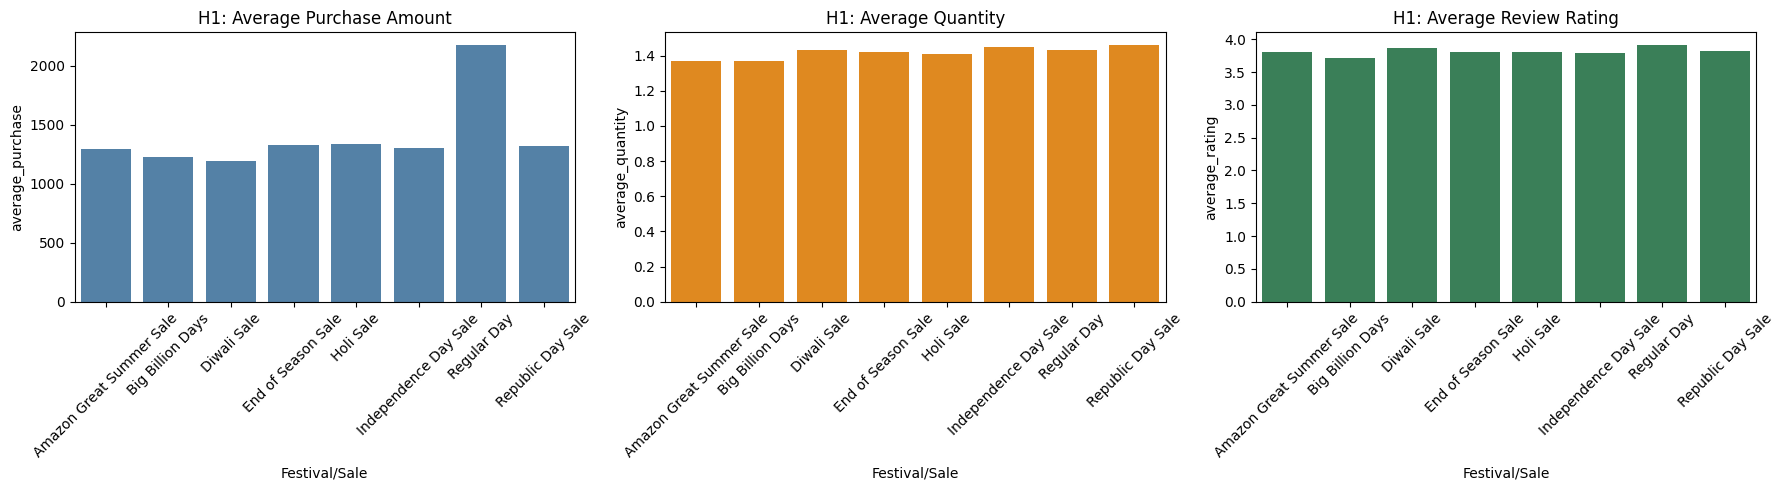

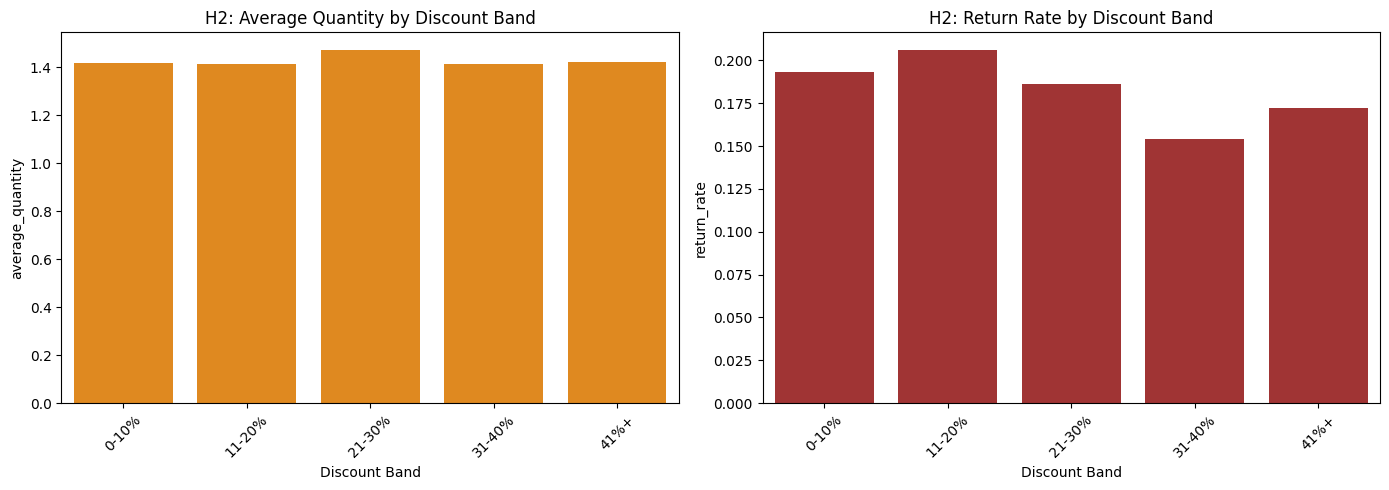

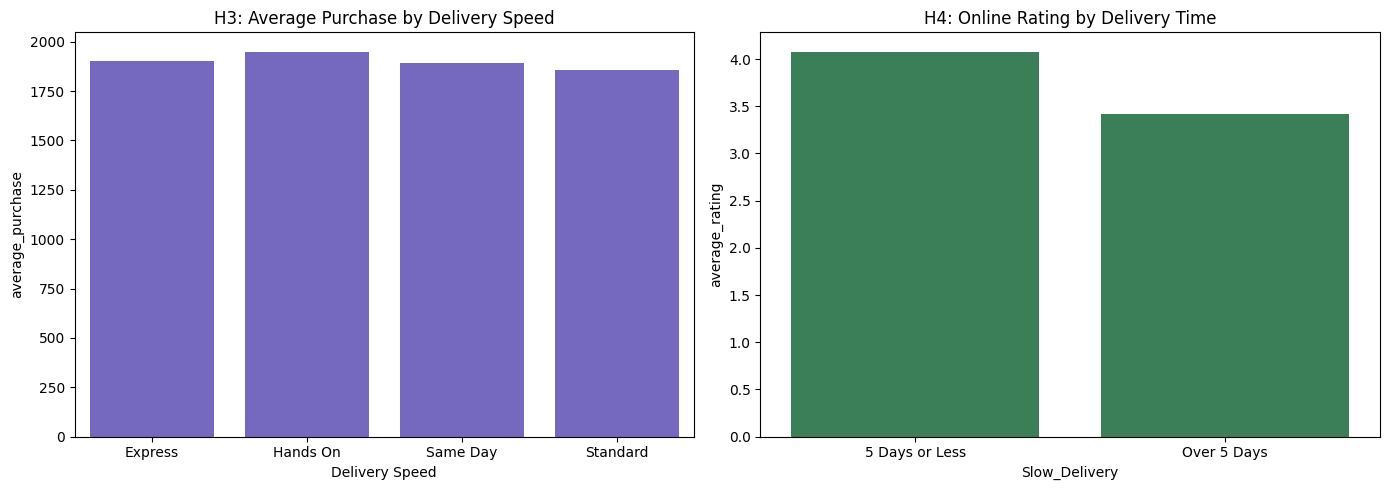

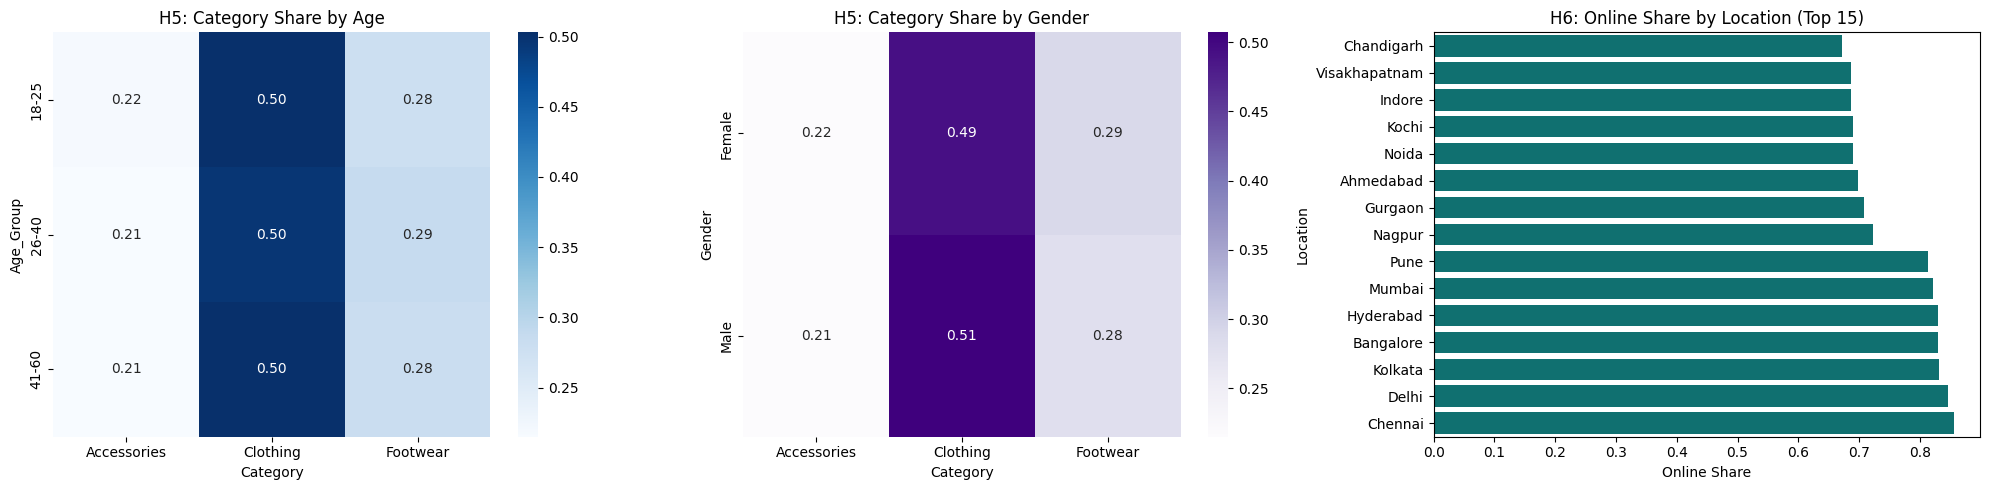

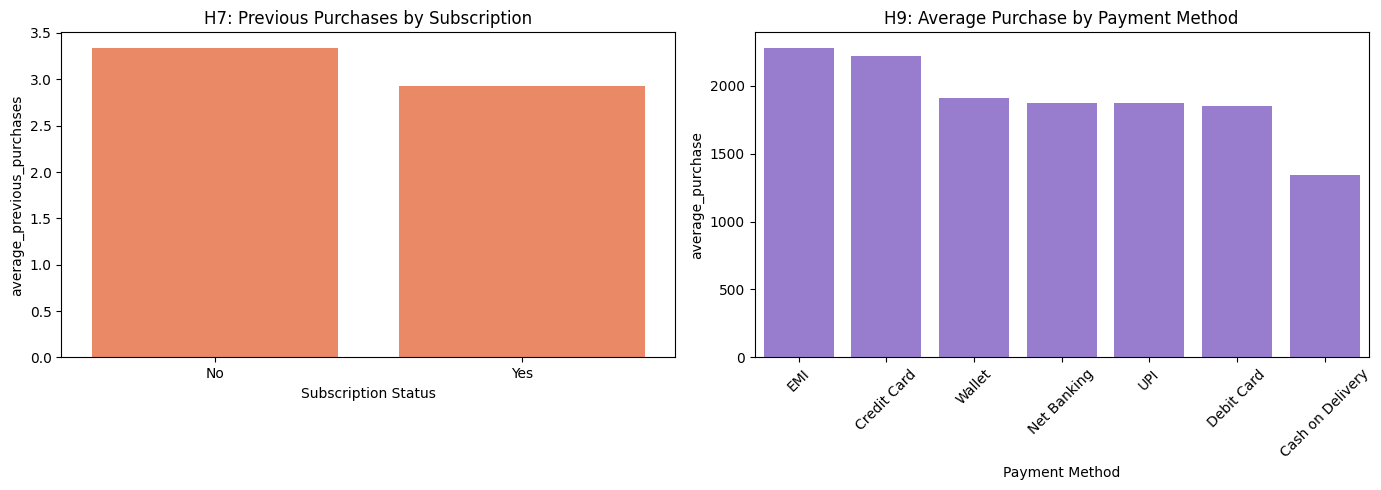

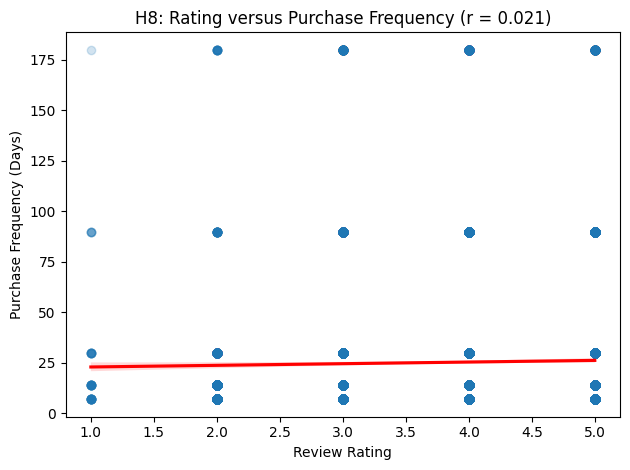

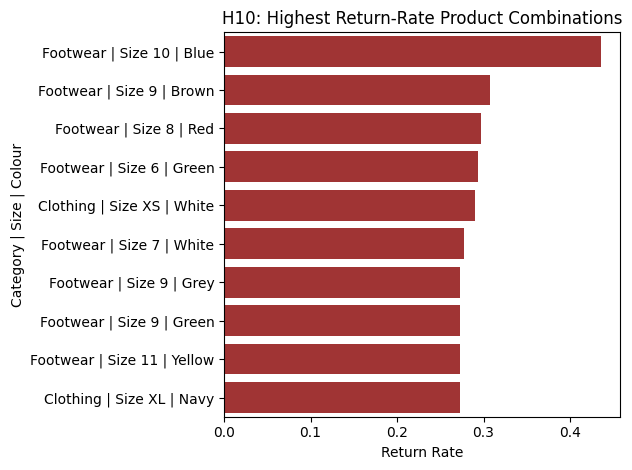

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# H1: Festival/Sale versus regular-day purchase behaviour.
festival_plot = festival_summary.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=festival_plot, x='Festival/Sale', y='average_purchase', ax=axes[0], color='steelblue')
sns.barplot(data=festival_plot, x='Festival/Sale', y='average_quantity', ax=axes[1], color='darkorange')
sns.barplot(data=festival_plot, x='Festival/Sale', y='average_rating', ax=axes[2], color='seagreen')
axes[0].set_title('H1: Average Purchase Amount')
axes[1].set_title('H1: Average Quantity')
axes[2].set_title('H1: Average Review Rating')
for axis in axes:
    axis.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# H2: Discount bands compared with quantity and return rate.
discount_plot = discount_summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=discount_plot, x='Discount_Band', y='average_quantity', ax=axes[0], color='darkorange')
sns.barplot(data=discount_plot, x='Discount_Band', y='return_rate', ax=axes[1], color='firebrick')
axes[0].set_title('H2: Average Quantity by Discount Band')
axes[1].set_title('H2: Return Rate by Discount Band')
for axis in axes:
    axis.set_xlabel('Discount Band')
    axis.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# H3 and H4: Shipping/delivery outcomes.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=shipping_summary.reset_index(), x='Delivery Speed', y='average_purchase', ax=axes[0], color='slateblue')
sns.barplot(data=h4_summary.reset_index(), x='Slow_Delivery', y='average_rating', ax=axes[1], color='seagreen')
axes[0].set_title('H3: Average Purchase by Delivery Speed')
axes[1].set_title('H4: Online Rating by Delivery Time')
axes[1].set_xticks([0, 1], ['5 Days or Less', 'Over 5 Days'])
plt.tight_layout()
plt.show()

# H5 and H6: Demographics and location/channel preference.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.heatmap(h5_category, annot=True, fmt='.2f', cmap='Blues', ax=axes[0])
sns.heatmap(h5_gender, annot=True, fmt='.2f', cmap='Purples', ax=axes[1])
location_plot = h6_location.sort_values('online_share').tail(15).reset_index()
sns.barplot(data=location_plot, x='online_share', y='Location', ax=axes[2], color='teal')
axes[0].set_title('H5: Category Share by Age')
axes[1].set_title('H5: Category Share by Gender')
axes[2].set_title('H6: Online Share by Location (Top 15)')
axes[2].set_xlabel('Online Share')
plt.tight_layout()
plt.show()

# H7 and H9: Subscription loyalty and payment-method spending.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=h7_subscription.reset_index(), x='Subscription Status', y='average_previous_purchases', ax=axes[0], color='coral')
sns.barplot(data=h9_payment.reset_index(), x='Payment Method', y='average_purchase', ax=axes[1], color='mediumpurple')
axes[0].set_title('H7: Previous Purchases by Subscription')
axes[1].set_title('H9: Average Purchase by Payment Method')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# H8: Rating and purchase-frequency relationship.
sns.regplot(
    data=df_clean,
    x='Review Rating',
    y='Purchase_Frequency_Days',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'red'}
)
plt.title(f'H8: Rating versus Purchase Frequency (r = {h8_correlation:.3f})')
plt.xlabel('Review Rating')
plt.ylabel('Purchase Frequency (Days)')
plt.tight_layout()
plt.show()

# H10: Highest-return combinations with at least 30 transactions.
h10_plot = h10_groups.reset_index().copy()
h10_plot['Combination'] = (
    h10_plot['Category'] + ' | Size ' + h10_plot['Size'].astype(str)
    + ' | ' + h10_plot['Color']
)
sns.barplot(data=h10_plot, x='return_rate', y='Combination', color='firebrick')
plt.title('H10: Highest Return-Rate Product Combinations')
plt.xlabel('Return Rate')
plt.ylabel('Category | Size | Colour')
plt.tight_layout()
plt.show()